1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

2.Load and Explore Data

In [4]:
from sklearn.datasets import load_iris
iris=load_iris()
X=pd.DataFrame(iris.data, columns=iris.feature_names)
y=pd.Series(iris.target, name="species")

In [6]:
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [8]:
print(y.value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


3.Normalize the Feature

In [11]:
#Normalize features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

4.Train/Test Split

In [14]:
#split dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

5.KNN classification & experiment with K

In [17]:
#implement KNN classifier with different values of K
for k in range(1,11):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    print(f"K={k} --> Accuracy : {acc: .2f}")

K=1 --> Accuracy :  0.97
K=2 --> Accuracy :  1.00
K=3 --> Accuracy :  1.00
K=4 --> Accuracy :  1.00
K=5 --> Accuracy :  1.00
K=6 --> Accuracy :  1.00
K=7 --> Accuracy :  1.00
K=8 --> Accuracy :  1.00
K=9 --> Accuracy :  1.00
K=10 --> Accuracy :  1.00


6.Evaluate Best K with Confusion Matrix

In [20]:
best_k=3
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

accuracy: 1.0
confusion matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


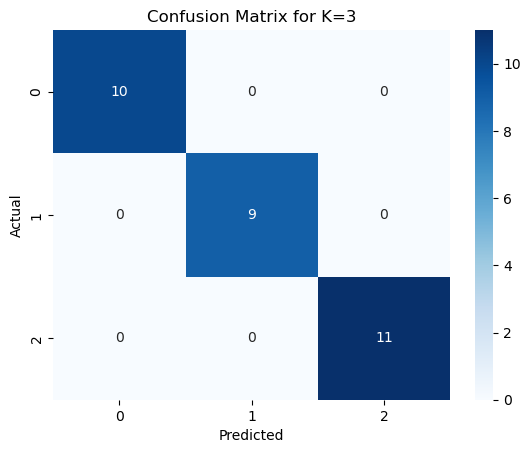

In [22]:
#Evaluate model using accuracy and confusiin matrix
cnm=confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)
print("confusion matrix:",cnm)
sns.heatmap(cnm,annot=True,cmap="Blues",fmt="d")
plt.title(f"Confusion Matrix for K={best_k}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7.Visualize Decision Boundaries

*Only works with 2 features - so reduce features

In [25]:
from matplotlib.colors import ListedColormap
X_2d=X_scaled[:, :2] #only first 2 features
X_train2,X_test2,y_train2,y_test2=train_test_split(X_2d,y, test_size=0.2,random_state=42)

In [27]:
knn=KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train2,y_train2)

KNeighborsClassifier(n_neighbors=3)

In [29]:
#Create Meshgrid for visualization
#Predict on Meshgrid 
h=.02
x_min, x_max=X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min ,y_max=X_2d[:, 0].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min,x_max,h),
                     np.arange(y_min,y_max,h))

In [31]:
Z=knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)

C:\Users\USER\AppData\Local\Temp\ipykernel_10500\2555811411.py:3: UserWarning: The following kwargs were not used by contour: 'aplha'
  plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']),aplha=0.5)


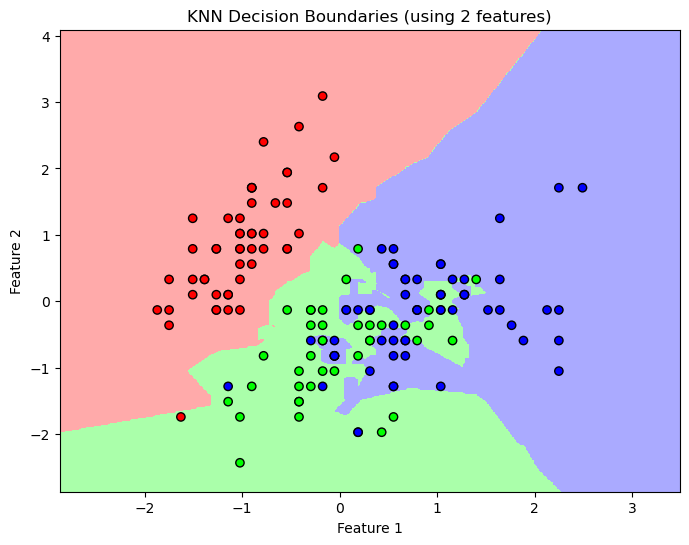

In [32]:
#plot Decision Boundaries
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']),aplha=0.5)
plt.scatter(X_2d[0:, 0], X_2d[:, 1], c=y, edgecolor='k', cmap=ListedColormap(['#FF0000','#00FF00','#0000FF']))
plt.title("KNN Decision Boundaries (using 2 features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()